# Facial Keypoint Detection — Entrenamiento 

## 1. Imports

In [1]:
#%pip install torch torchvision

import os
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Usando CUDA (NVIDIA GPU): {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
    print('CUDA no disponible, usando CPU.')

Usando CUDA (NVIDIA GPU): NVIDIA GeForce RTX 2070


## 2. Configuración

In [ ]:

DATA_DIR    = r'C:\Users\guill\OneDrive\Escritorio\repositorios-uni\deep-final-alpha\Data'
IMAGES_PATH    = os.path.join(DATA_DIR, 'preprocessed', 'images_50k.npy')
KEYPOINTS_PATH = os.path.join(DATA_DIR, 'preprocessed', 'keypoints_50k.npy')
MODEL_PATH     = os.path.join(DATA_DIR, 'best_baseline_cnn.pth')
LOSSES_PATH    = os.path.join(DATA_DIR, 'training_losses.pkl')

IMG_SIZE    = 96
BATCH_SIZE  = 64
NUM_EPOCHS  = 20
LR          = 1e-3
SEED        = 42

print(f'IMAGES_PATH:    {IMAGES_PATH}')
print(f'KEYPOINTS_PATH: {KEYPOINTS_PATH}')
print(f'NUM_EPOCHS:     {NUM_EPOCHS}')
print(f'BATCH_SIZE:     {BATCH_SIZE}')


IMAGES_PATH:    C:\Users\guill\OneDrive\Escritorio\repositorios-uni\deep-final-alpha\Data\preprocessed\images_50k.npy
KEYPOINTS_PATH: C:\Users\guill\OneDrive\Escritorio\repositorios-uni\deep-final-alpha\Data\preprocessed\keypoints_50k.npy
NUM_EPOCHS:     20
BATCH_SIZE:     64


## 3. Cargar datos y crear DataLoaders

In [3]:
class FacialKeypointDataset(Dataset):
    """Dataset en memoria: carga todo de golpe desde .npy, rapidísimo."""
    def __init__(self, images, keypoints):
        # images:    (N, 3, 96, 96) float32
        # keypoints: (N, 136)       float32
        self.images    = torch.tensor(images,    dtype=torch.float32)
        self.keypoints = torch.tensor(keypoints, dtype=torch.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.keypoints[idx]


# Cargar arrays preprocesados
print('Cargando imágenes desde disco...')
images    = np.load(IMAGES_PATH)
keypoints = np.load(KEYPOINTS_PATH)
print(f'images:    {images.shape}   {images.nbytes / 1e9:.2f} GB')
print(f'keypoints: {keypoints.shape}   {keypoints.nbytes / 1e6:.1f} MB')

# Dataset y split 80/20
full_dataset = FacialKeypointDataset(images, keypoints)
torch.manual_seed(SEED)
train_size    = int(0.8 * len(full_dataset))
val_size      = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'\nTrain: {len(train_dataset):,} frames  ({len(train_loader)} batches)')
print(f'Val:   {len(val_dataset):,} frames  ({len(val_loader)} batches)')

imgs_b, kps_b = next(iter(train_loader))
print(f'\nBatch imágenes:  {imgs_b.shape}')
print(f'Batch keypoints: {kps_b.shape}')


Cargando imágenes desde disco...
images:    (50000, 3, 96, 96)   5.53 GB
keypoints: (50000, 136)   27.2 MB

Train: 40,000 frames  (625 batches)
Val:   10,000 frames  (157 batches)

Batch imágenes:  torch.Size([64, 3, 96, 96])
Batch keypoints: torch.Size([64, 136])


## 4. Modelo — CNN Baseline

In [4]:
class BaselineCNN(nn.Module):
    def __init__(self, num_keypoints=68):
        super().__init__()
        out_dim = num_keypoints * 2
        self.features = nn.Sequential(
            nn.Conv2d(3,   32, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32,  64, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128,256, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 1024), nn.ReLU(inplace=True),
            nn.Linear(1024, 256),          nn.ReLU(inplace=True),
            nn.Linear(256, out_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.regressor(self.features(x))


model = BaselineCNN().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {total_params:,}')

with torch.no_grad():
    dummy = torch.zeros(4, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = model(dummy)
    print(f'Input:  {dummy.shape}  →  Output: {out.shape}')


Parámetros entrenables: 10,123,976
Input:  torch.Size([4, 3, 96, 96])  →  Output: torch.Size([4, 136])


## 5. Loss y optimizador

In [5]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)
print('Loss:      MSELoss')
print('Optimizer: Adam  lr=1e-3')
print('Scheduler: ReduceLROnPlateau  factor=0.5  patience=3')


Loss:      MSELoss
Optimizer: Adam  lr=1e-3
Scheduler: ReduceLROnPlateau  factor=0.5  patience=3


## 6. Entrenamiento

In [ ]:
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, NUM_EPOCHS + 1):

    #Train
    model.train()
    running_loss = 0.0
    for imgs, kps in train_loader:
        imgs, kps = imgs.to(device), kps.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), kps)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_dataset)

    #Validation 
    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for imgs, kps in val_loader:
            imgs, kps = imgs.to(device), kps.to(device)
            running_val += criterion(model(imgs), kps).item() * imgs.size(0)
    val_loss = running_val / len(val_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        saved_marker = '  ✅'
    else:
        saved_marker = ''

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
          f'train: {train_loss:.6f}  '
          f'val: {val_loss:.6f}  '
          f'lr: {current_lr:.2e}'
          f'{saved_marker}')

print(f'\nMejor val_loss: {best_val_loss:.6f}')
print(f'Modelo guardado en: {MODEL_PATH}')

with open(LOSSES_PATH, 'wb') as f:
    pickle.dump({'train': train_losses, 'val': val_losses}, f)
print(f'Losses guardadas en: {LOSSES_PATH}')


Epoch  1/20  train: 0.001787  val: 0.000575  lr: 1.00e-03  ✅
Epoch  2/20  train: 0.000304  val: 0.000219  lr: 1.00e-03  ✅
Epoch  3/20  train: 0.000160  val: 0.000142  lr: 1.00e-03  ✅
Epoch  4/20  train: 0.000117  val: 0.000113  lr: 1.00e-03  ✅
Epoch  5/20  train: 0.000100  val: 0.000106  lr: 1.00e-03  ✅
Epoch  6/20  train: 0.000090  val: 0.000100  lr: 1.00e-03  ✅
Epoch  7/20  train: 0.000083  val: 0.000089  lr: 1.00e-03  ✅
Epoch  8/20  train: 0.000078  val: 0.000093  lr: 1.00e-03
Epoch  9/20  train: 0.000072  val: 0.000084  lr: 1.00e-03  ✅
Epoch 10/20  train: 0.000070  val: 0.000083  lr: 1.00e-03  ✅
Epoch 11/20  train: 0.000067  val: 0.000077  lr: 1.00e-03  ✅
Epoch 12/20  train: 0.000064  val: 0.000081  lr: 1.00e-03
Epoch 13/20  train: 0.000062  val: 0.000074  lr: 1.00e-03  ✅
Epoch 14/20  train: 0.000061  val: 0.000073  lr: 1.00e-03  ✅
Epoch 15/20  train: 0.000058  val: 0.000076  lr: 1.00e-03
Epoch 16/20  train: 0.000057  val: 0.000072  lr: 1.00e-03  ✅
Epoch 17/20  train: 0.000057  val

## 7. Curva de pérdida

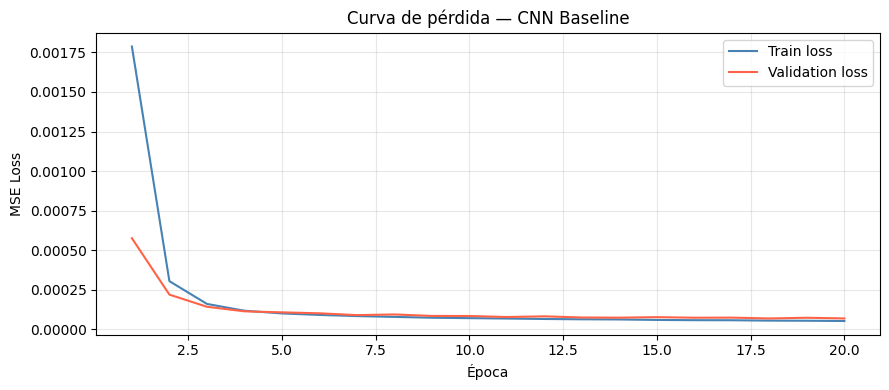

In [8]:
epochs = range(1, len(train_losses) + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, train_losses, label='Train loss',      color='steelblue')
ax.plot(epochs, val_losses,   label='Validation loss', color='tomato')
ax.set_xlabel('Época'); ax.set_ylabel('MSE Loss')
ax.set_title('Curva de pérdida — CNN Baseline')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
